In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif,SelectKBest, chi2,RFE,SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report,precision_recall_fscore_support
from sklearn.model_selection import cross_val_score, cross_val_predict 
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [27]:

#import data and explore data
df = pd.read_csv("Dataset_Study3.csv")
print(df.head())
print("info " , df.info())
print("Desc" ,df.describe())
print("Is null ",df.isnull().value_counts())
print("is duplicate: ",df.duplicated().value_counts())

y = df['Label']
df.drop('Label',axis =1,inplace =True)

#Standard scaling data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(data_scaled,columns=df.columns)
print(X_scaled.head)

#X_scaled.columns


   HRV_MeanNN   HRV_SDNN  HRV_RMSSD  HRV_Prc20NN  HRV_Prc80NN  HRV_pNN50  \
0  838.708920  77.858966  42.966689        773.2        907.4  21.962617   
1  899.929293  80.454862  50.910712        838.6        960.4  24.623116   
2  827.319444  64.428505  40.450375        766.4        881.8  20.276498   
3  768.630901  76.803474  43.512943        699.0        837.4  23.076923   
4  807.432432  82.942629  49.326201        731.0        879.2  18.834081   

     HRV_HTI     HRV_VLF       HRV_LF      HRV_HF       HRV_TP  HRV_LFHF  \
0  15.285714  135.219052  1984.443232  941.576892  3083.350848  2.107574   
1  15.307692   77.009053  1012.790954  712.205460  1835.167749  1.422049   
2  15.500000  129.751167  1924.529470  761.893623  2848.723565  2.525982   
3  16.714286  163.822696  4643.049228  806.486463  5625.889299  5.757132   
4  13.937500  132.967712  2348.301339  567.338064  3066.742236  4.139157   

     HRV_SD1     HRV_SD2  HRV_SD1SD2  HRV_DFA_alpha1  HRV_DFA_alpha2  \
0  30.452465  

Visualise data

array([[<Axes: title={'center': 'HRV_MeanNN'}>,
        <Axes: title={'center': 'HRV_SDNN'}>,
        <Axes: title={'center': 'HRV_RMSSD'}>,
        <Axes: title={'center': 'HRV_Prc20NN'}>],
       [<Axes: title={'center': 'HRV_Prc80NN'}>,
        <Axes: title={'center': 'HRV_pNN50'}>,
        <Axes: title={'center': 'HRV_HTI'}>,
        <Axes: title={'center': 'HRV_VLF'}>],
       [<Axes: title={'center': 'HRV_LF'}>,
        <Axes: title={'center': 'HRV_HF'}>,
        <Axes: title={'center': 'HRV_TP'}>,
        <Axes: title={'center': 'HRV_LFHF'}>],
       [<Axes: title={'center': 'HRV_SD1'}>,
        <Axes: title={'center': 'HRV_SD2'}>,
        <Axes: title={'center': 'HRV_SD1SD2'}>,
        <Axes: title={'center': 'HRV_DFA_alpha1'}>],
       [<Axes: title={'center': 'HRV_DFA_alpha2'}>,
        <Axes: title={'center': 'HRV_ApEn'}>,
        <Axes: title={'center': 'HRV_SampEn'}>, <Axes: >]], dtype=object)

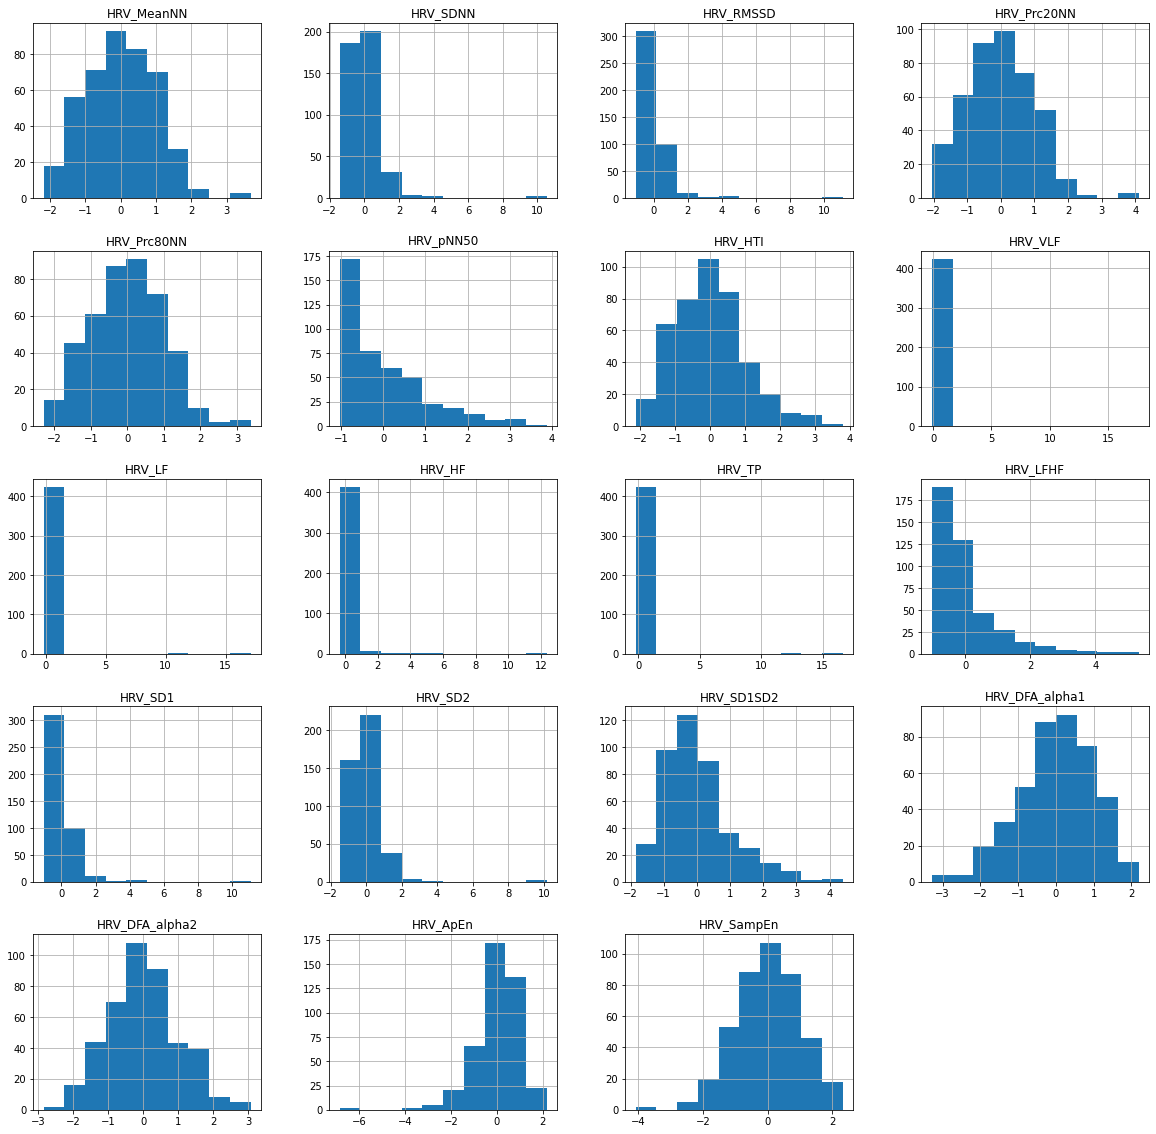

In [28]:
#histogram
X_scaled.hist(figsize=(20,20))

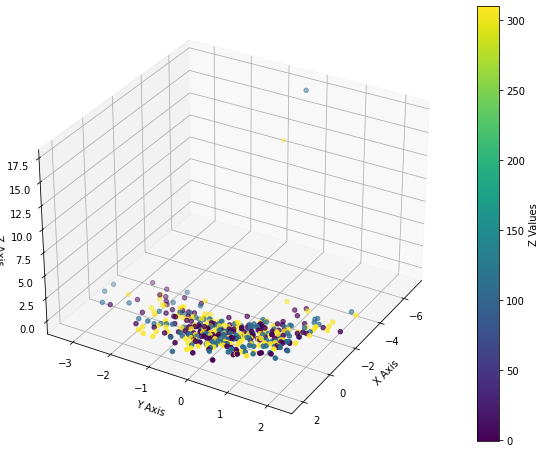

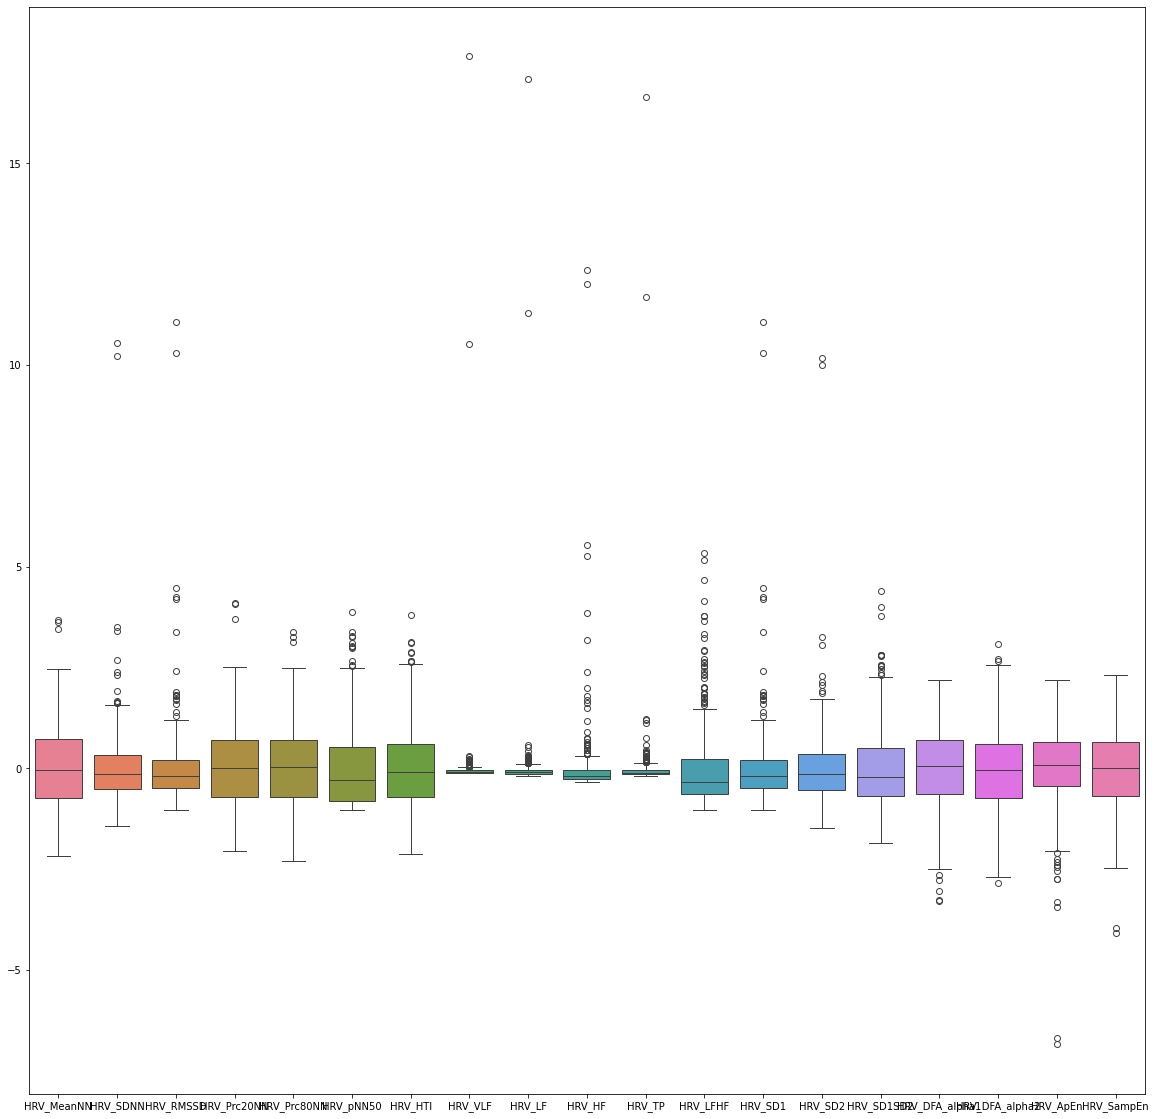

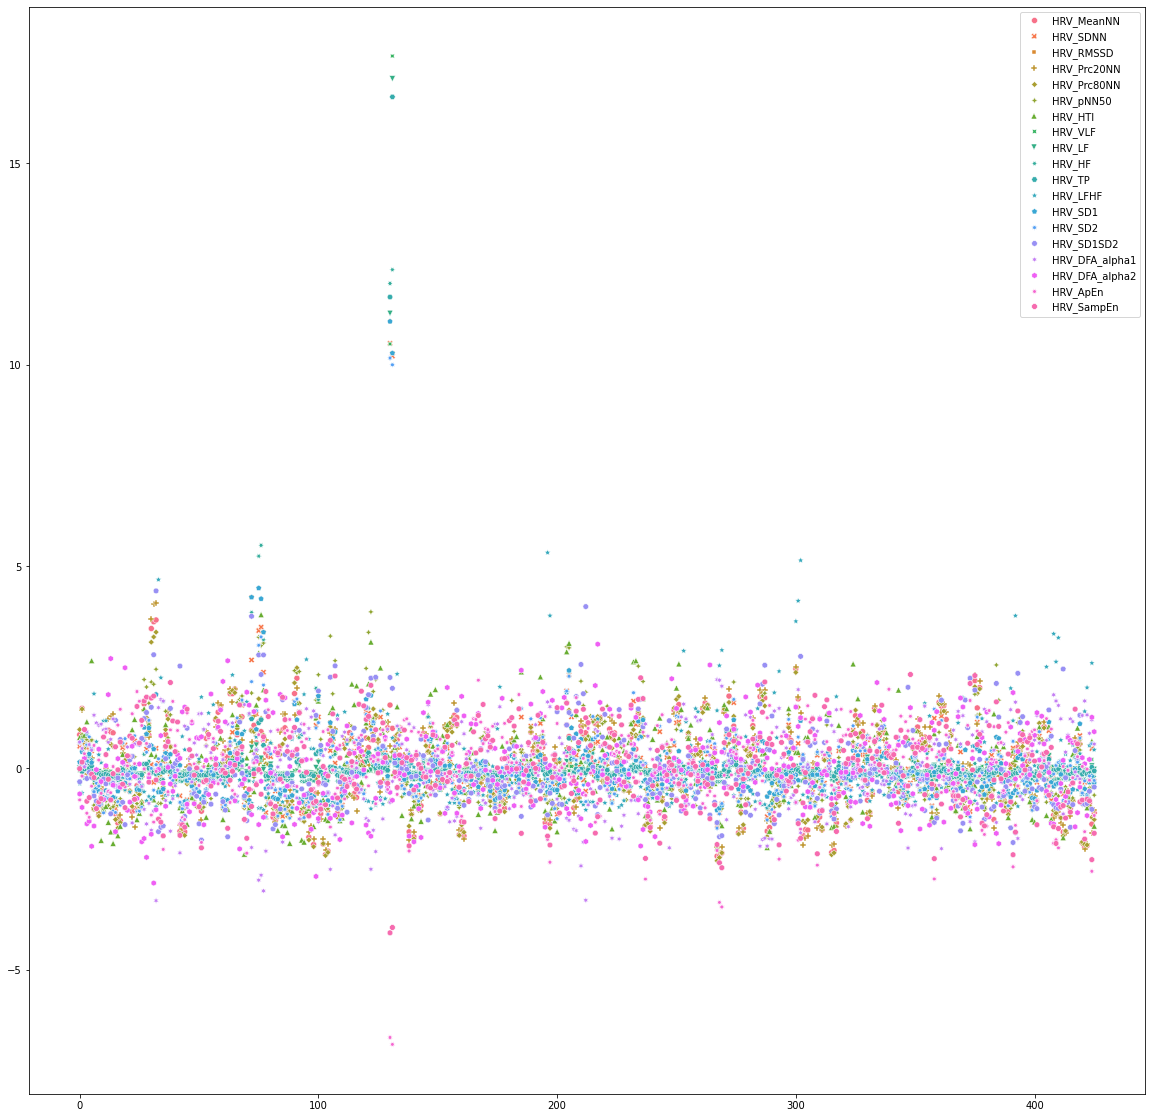

In [23]:

# Create a scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_scaled['HRV_ApEn'],X_scaled['HRV_DFA_alpha1'],X_scaled['HRV_LF'], c=y, cmap='viridis')

# Customize plot appearance
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
cbar = fig.colorbar(scatter)
cbar.set_label('Z Values')

# Change the perspective (adjust the viewing angle)
ax.view_init(elev=30, azim=30)

plt.show()

plt.figure(figsize=(20,20))
sns.boxplot(X_scaled)
plt.show()
plt.figure(figsize=(20,20))
sns.scatterplot(X_scaled)
plt.show()


In [4]:
y.value_counts()

-1      142
 310    142
 109    142
Name: Label, dtype: int64

Feature Selection

Index(['HRV_MeanNN', 'HRV_SDNN', 'HRV_pNN50', 'HRV_HTI', 'HRV_VLF', 'HRV_LFHF',
       'HRV_SD1SD2', 'HRV_DFA_alpha2', 'HRV_ApEn', 'HRV_SampEn'],
      dtype='object')


<Axes: >

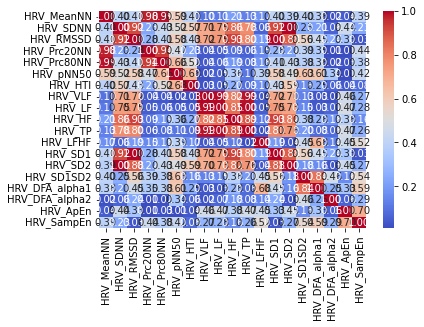

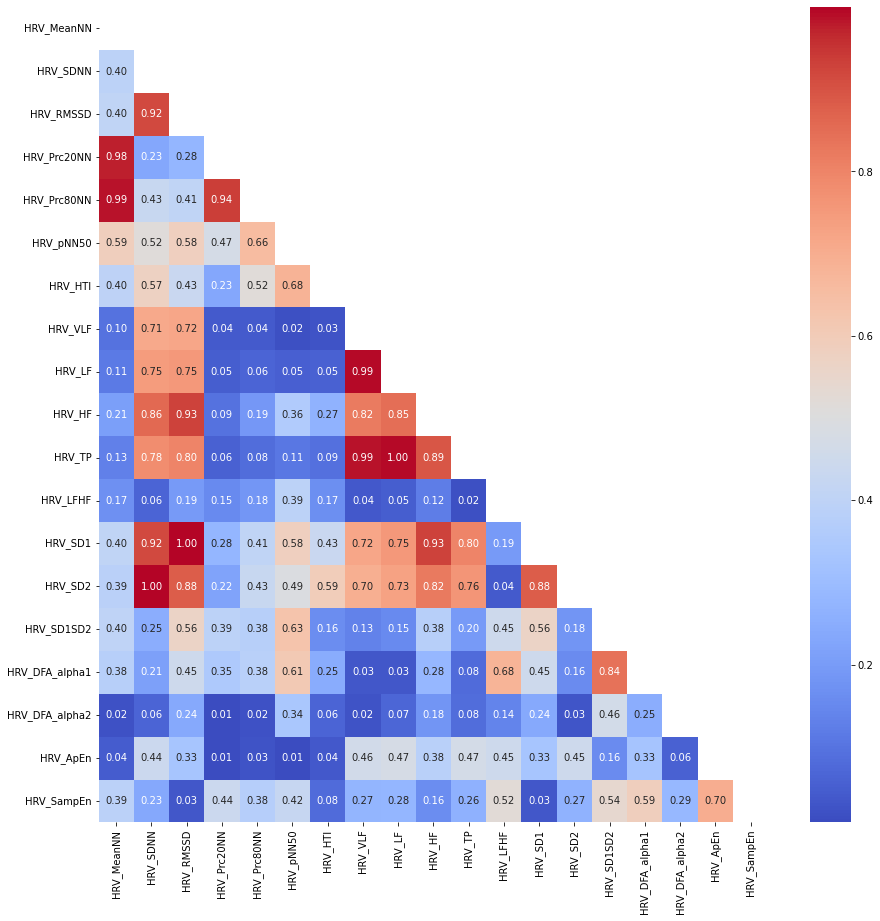

In [17]:
#filter method
#correlation matrix shows the  degree of relationship between variables in a dataset.

correlation_matrix = X_scaled.corr().abs()
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt="0.2f")
# Create a mask to exclude the upper triangle of the correlation matrix (to avoid duplicates)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
# Identify features with correlation above a certain threshold
threshold = 0.8
correlated_features = [column for column in range(len(correlation_matrix.columns)) if any(correlation_matrix.iloc[:column, column] > threshold)]
# Drop the highly correlated features
# droping correlated(similar features allows to simplify the data for the model of classification)
selected_features = X_scaled.drop(columns=X_scaled.columns[correlated_features])
print(selected_features.columns)
plt.figure(figsize=(15,15))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt="0.2f",mask=mask)


In [74]:
#filter method
#mutual info gain
#Mutual information (MI) [1] between two random variables is a non-negative value, which measures the dependency between the variables. 
#It is equal to zero if and only if two random variables are independent, and higher values mean higher dependency
#use k-nearest neighbors distance
# Calculate information gain for each feature       
info_gain = mutual_info_classif(X_scaled, y)
feature_info_gain = pd.DataFrame({'Feature': X_scaled.columns, 'Info Gain': info_gain})
top = feature_info_gain.sort_values(by='Info Gain', ascending=False,inplace=False)
top = top.head(10)
print("Feature Information Gain:")
print(list(top['Feature']))

Feature Information Gain:
['HRV_SD1SD2', 'HRV_DFA_alpha1', 'HRV_MeanNN', 'HRV_ApEn', 'HRV_HF', 'HRV_pNN50', 'HRV_HTI', 'HRV_VLF', 'HRV_LF', 'HRV_SDNN']


In [3]:
# selct k best w.r.t chi-score
k_best =  SelectKBest(chi2, k=10)  # Set 'k' to the desired number of features
X_train_chi2 = k_best.fit_transform(X_scaled, y)
X_test_chi2 = k_best.transform(X_scaled)
# Get the selected feature indices
selected_feature_indices = k_best.get_support(indices=True)
# Get the names of the selected features
selected_feature_names_chi = X_scaled.feature_names[selected_feature_indices]
# Print or use the selected features
print("Selected Features based on Chi-squared:")
print(selected_feature_names_chi)


ValueError: Input X must be non-negative.

In [7]:
#recursive feature elimination based on logistic regression
#wrapper model
#Logistic regression allows to select the least important features and  RFE removes them

model = LogisticRegression()
rfe = RFE(model, n_features_to_select=10) # Selecting top 5 features
fit = rfe.fit(X_scaled, y)
# Print the selected features
selected_features2 = [f for f, s in zip(df.columns, fit.support_) if s]
print("Selected Features: ", selected_features2)


Selected Features:  ['HRV_RMSSD', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_TP', 'HRV_SD1', 'HRV_SD1SD2', 'HRV_DFA_alpha1', 'HRV_ApEn', 'HRV_SampEn']


In [8]:
# Forward Selection using SFS from sklearn
#wrapper method
#adding one feature at a time until the model performance  does not improve significantly.
#sfs+logistic regression 
sfs_forward = SFS(estimator=model,n_features_to_select=10,direction='forward',scoring='accuracy',cv=5)
sfs_forward = sfs_forward.fit(X_scaled, y)
cols = df.columns[sfs_forward.get_support()==True]
print(cols)

Index(['HRV_MeanNN', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_VLF', 'HRV_LF',
       'HRV_HF', 'HRV_TP', 'HRV_LFHF', 'HRV_SD1SD2', 'HRV_DFA_alpha2'],
      dtype='object')


In [9]:
sfs_backward = SFS(estimator=model,n_features_to_select=10, direction='backward',scoring='accuracy',cv=5)
sfs_backward = sfs_backward.fit(X_scaled, y)
cols_b = df.columns[sfs_backward.get_support()==True]
cols_b


Index(['HRV_MeanNN', 'HRV_Prc20NN', 'HRV_HTI', 'HRV_VLF', 'HRV_LF', 'HRV_HF',
       'HRV_LFHF', 'HRV_SD1', 'HRV_SD2', 'HRV_DFA_alpha2'],
      dtype='object')

In [13]:
# RandomForestClassifier for feature importance
#feature importnace  is the measure of how much each individual variable affects the model.
rf_model = RandomForestClassifier()
rf_model.fit(X_scaled, y)
# Extracting feature importances
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]
top_features_rf = X_scaled.columns[rf_indices[:10]]
print(top_features_rf)

Index(['HRV_DFA_alpha2', 'HRV_SD1SD2', 'HRV_DFA_alpha1', 'HRV_VLF', 'HRV_HTI',
       'HRV_SampEn', 'HRV_LFHF', 'HRV_SDNN', 'HRV_Prc80NN', 'HRV_HF'],
      dtype='object')


In [59]:
#embedded 
# DecisionTreeClassifier for feature importance
dtree_model = DecisionTreeClassifier(random_state=0)
dtree_model.fit(X_scaled, y)
# Extracting feature importances
dtree_importances = dtree_model.feature_importances_
dtree_indices = np.argsort(dtree_importances)[::-1]
top_features_dtree = X_scaled.columns[dtree_indices[:10]]
print(top_features_dtree)



Index(['HRV_DFA_alpha2', 'HRV_LF', 'HRV_HTI', 'HRV_LFHF', 'HRV_Prc20NN',
       'HRV_DFA_alpha1', 'HRV_VLF', 'HRV_SampEn', 'HRV_SD1SD2', 'HRV_HF'],
      dtype='object')


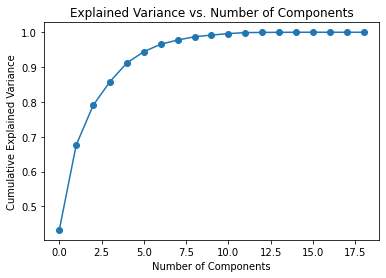

Explained Variance Ratio:
['HRV_MeanNN', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_RMSSD', 'HRV_SDNN']


In [22]:
#pCA
pca = PCA()
pca.fit(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.plot(cumulative_explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()

pca = PCA(n_components=5)  # Set the number of components you want
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train_pca = pca.fit_transform(X_scaled)
X_test_pca = pca.transform(X_test)
print("Explained Variance Ratio:")
print(sorted(pca.feature_names_in_[:5]))

In [6]:
l = ['HRV_MeanNN',      'HRV_SDNN',         'HRV_pNN50',    'HRV_HTI',          'HRV_VLF',          'HRV_LFHF',   
    'HRV_SD1SD2',       'HRV_DFA_alpha2',   'HRV_ApEn',     'HRV_SampEn',       'HRV_SD1SD2',       'HRV_Prc80NN',
    'HRV_DFA_alpha1',   'HRV_MeanNN',       'HRV_ApEn',     'HRV_HTI',          'HRV_HF',           'HRV_pNN50',    
    'HRV_VLF',          'HRV_LF',           'HRV_SDNN',     'HRV_RMSSD',        'HRV_VLF',          'HRV_LF',       
    'HRV_TP',           'HRV_SD1',          'HRV_SD1SD2',   'HRV_DFA_alpha1',   'HRV_ApEn',         'HRV_SampEn',  
    'HRV_MeanNN',       'HRV_Prc20NN',      'HRV_Prc80NN',  'HRV_VLF',          'HRV_LF',           'HRV_HF',    
    'HRV_TP',           'HRV_LFHF',         'HRV_SD1SD2',   'HRV_DFA_alpha2',   'HRV_MeanNN',       'HRV_Prc20NN',    
    'HRV_HTI',          'HRV_VLF',          'HRV_LF',       'HRV_HF',           'HRV_LFHF',         'HRV_SD1',         
    'HRV_DFA_alpha2',   'HRV_DFA_alpha2',   'HRV_VLF',      'HRV_SampEn',       'HRV_DFA_alpha1',   
    'HRV_SD1SD2',       'HRV_LFHF',         'HRV_ApEn',     'HRV_HTI',          'HRV_LF',           'HRV_HF',         
    'HRV_LF',           'HRV_HTI',          'HRV_LFHF',     'HRV_Prc20NN',      'HRV_DFA_alpha1',   'HRV_VLF',  
    'HRV_SampEn',       'HRV_SD1SD2',       'HRV_HF',       'HRV_MeanNN' ,      'HRV_SDNN',         'HRV_RMSSD',     
    'HRV_pNN50',        'HRV_HTI',          'HRV_VLF',      'HRV_LF' ,          'HRV_HF',           'HRV_TP',          
    'HRV_SD1',          'HRV_SD2',          'HRV_SD1SD2' ,  'HRV_DFA_alpha1',   'HRV_DFA_alpha2',  'HRV_Prc20NN' ,   
    'HRV_ApEn' ,        'HRV_SampEn',       'HRV_HF',       'HRV_SD2',          'HRV_DFA_alpha2',  'HRV_LFHF',
    'HRV_Prc80NN', 'HRV_pNN50', 'HRV_VLF', 'HRV_LF', 'HRV_TP', 'HRV_LFHF',
       'HRV_SD1SD2', 'HRV_DFA_alpha1', 'HRV_DFA_alpha2', 'HRV_SampEn']


from collections import Counter# Count occurrences
occurrences = Counter(l)
# Print the result
for element,     count in sorted(occurrences.items(),    key=lambda x: x[1],    reverse=True):
    print(f"{element}: {count} times")

HRV_VLF: 9 times
HRV_SD1SD2: 8 times
HRV_LF: 8 times
HRV_LFHF: 7 times
HRV_DFA_alpha2: 7 times
HRV_HF: 7 times
HRV_HTI: 6 times
HRV_SampEn: 6 times
HRV_DFA_alpha1: 6 times
HRV_MeanNN: 5 times
HRV_ApEn: 5 times
HRV_pNN50: 4 times
HRV_TP: 4 times
HRV_Prc20NN: 4 times
HRV_SDNN: 3 times
HRV_Prc80NN: 3 times
HRV_SD1: 3 times
HRV_RMSSD: 2 times
HRV_SD2: 2 times


Classification

In [79]:
# create a new df with selected features
sel = ['HRV_VLF','HRV_SD1SD2','HRV_HF','HRV_LF','HRV_HTI','HRV_LFHF','HRV_DFA_alpha2']
#sel = ['HRV_SDNN','HRV_pNN50','HRV_TP','HRV_SD1','HRV_RMSSD','HRV_Prc80NN','HRV_SD2'] #decreased
#sel = ['HRV_DFA_alpha2','HRV_MeanNN','HRV_ApEn','HRV_SampEn','HRV_DFA_alpha1','HRV_Prc20NN','HRV_SDNN']#decreased
#sel = ['HRV_HF', 'HRV_HTI', 'HRV_LF', 'HRV_MeanNN', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_RMSSD']#pca 

df_new = pd.concat([X_scaled[sel],y],axis=1)
df_new.head()
y = df_new['Label']
df_new.drop('Label',axis =1,inplace =True)
X_train,X_test,y_train,y_test = train_test_split(df_new,y,test_size=0.2,random_state=42)


In [80]:
#logistic
logistic = LogisticRegression()
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)
print(logistic.score(X_test,y_test))


0.3023255813953488


In [82]:

#dtree
dtree = DecisionTreeClassifier()
dtree.fit(X_train,y_train)
y_pred = dtree.predict(X_test)
print(dtree.score(X_test,y_test))


0.29069767441860467


[Text(0.7631168300653595, 0.9722222222222222, 'x[1] <= 0.852\ngini = 0.666\nsamples = 340\nvalue = [112, 117, 111]'),
 Text(0.6287173202614379, 0.9166666666666666, 'x[0] <= 0.113\ngini = 0.665\nsamples = 284\nvalue = [100, 100, 84]'),
 Text(0.4898529411764706, 0.8611111111111112, 'x[3] <= -0.077\ngini = 0.665\nsamples = 275\nvalue = [99, 93, 83]'),
 Text(0.26977124183006534, 0.8055555555555556, 'x[6] <= 0.435\ngini = 0.665\nsamples = 173\nvalue = [60, 52, 61]'),
 Text(0.18529411764705883, 0.75, 'x[4] <= -1.916\ngini = 0.659\nsamples = 110\nvalue = [30, 36, 44]'),
 Text(0.1769281045751634, 0.6944444444444444, 'gini = 0.0\nsamples = 3\nvalue = [3, 0, 0]'),
 Text(0.19366013071895424, 0.6944444444444444, 'x[2] <= -0.026\ngini = 0.654\nsamples = 107\nvalue = [27, 36, 44]'),
 Text(0.1318954248366013, 0.6388888888888888, 'x[2] <= -0.293\ngini = 0.65\nsamples = 96\nvalue = [25, 29, 42]'),
 Text(0.04183006535947712, 0.5833333333333334, 'x[3] <= -0.166\ngini = 0.569\nsamples = 24\nvalue = [2, 12

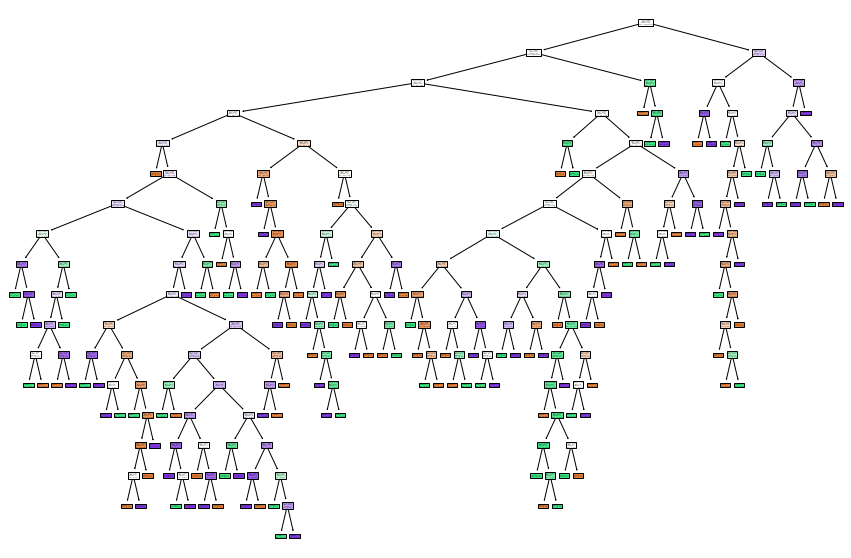

In [51]:
from sklearn import tree 
plt.figure(figsize=(15,10))
tree.plot_tree(dtree,filled=True,label='all')

In [23]:

#random forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(rf_model.score(X_test,y_test))

rf_model


0.2558139534883721


RandomForestClassifier()

In [24]:

#SVM
# C =regularization

svm_classifier = svm.SVC(kernel='linear', C=1.0, random_state=42)
svm_classifier.fit(X_train,y_train)
y_pred = svm_classifier.predict(X_test)
print(svm_classifier.score(X_test,y_test))

svm_classifier = svm.SVC(kernel='poly', C=1.0, random_state=42)
svm_classifier.fit(X_train,y_train)
y_pred = svm_classifier.predict(X_test)
print(svm_classifier.score(X_test,y_test))

svm_classifier = svm.SVC(kernel='rbf', C=1.0, random_state=42)
svm_classifier.fit(X_train,y_train)
y_pred = svm_classifier.predict(X_test)
print(svm_classifier.score(X_test,y_test))

svm_classifier = svm.SVC(kernel='sigmoid', C=1.0, random_state=42)
svm_classifier.fit(X_train,y_train)
svm_classifier.predict(X_test)
print(svm_classifier.score(X_test,y_test))


0.32558139534883723
0.27906976744186046
0.26744186046511625
0.29069767441860467


In [25]:
#knn
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
knn.predict(X_test)
print(knn.score(X_test,y_test))


0.32558139534883723


In [26]:
#naive bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)
# Make predictions on the test set
y_pred = gnb.predict(X_test)
print(gnb.score(X_test,y_test))


0.36046511627906974


In [27]:

#gradient boost
gbc = GradientBoostingClassifier(n_estimators=800, learning_rate= 1, max_depth=8, random_state=42)
gbc.fit(X_train, y_train)
# Make predictions on the test set
y_pred = gbc.predict(X_test)
print(gbc.score(X_test,y_test))


0.3023255813953488


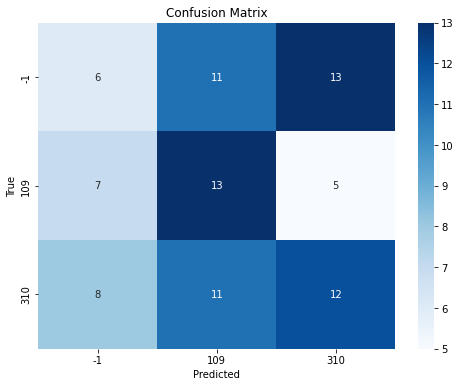

In [20]:

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [28]:
from sklearn.metrics import classification_report

# Function to perform cross-validation and return average metrics
def perform_cross_validation_with_metrics(model, X, y, cv=5):
    cv_predictions = cross_val_predict(model, X, y, cv=cv)
    
    # Calculate metrics
    accuracy = accuracy_score(y, cv_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(y, cv_predictions, average='weighted')
    
    return accuracy, precision, recall, f1

# Assuming 'logistic', 'svm', 'dtree', 'knn', 'gnb', 'gbc', 'rf_model' are your defined models
lr_accuracy, lr_precision, lr_recall, lr_f1 = perform_cross_validation_with_metrics(logistic, X_test, y_test)
# svm_accuracy, svm_precision, svm_recall, svm_f1 = perform_cross_validation_with_metrics(svm, X_test, y_test)
dt_accuracy, dt_precision, dt_recall, dt_f1 = perform_cross_validation_with_metrics(dtree, X_test, y_test)
knn_accuracy, knn_precision, knn_recall, knn_f1 = perform_cross_validation_with_metrics(knn, X_test, y_test)
nb_accuracy, nb_precision, nb_recall, nb_f1 = perform_cross_validation_with_metrics(gnb, X_test, y_test)
gbc_accuracy, gbc_precision, gbc_recall, gbc_f1 = perform_cross_validation_with_metrics(gbc, X_test, y_test)
rf_accuracy, rf_precision, rf_recall, rf_f1 = perform_cross_validation_with_metrics(rf_model, X_test, y_test)

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    "Model": ['Logistic Regression', 'Decision Tree', 'K-Nearest Neighbors', 'Naive Bayes', 'Gradient Boost', 'Random Forest'],
    "Accuracy": [lr_accuracy, dt_accuracy, knn_accuracy, nb_accuracy, gbc_accuracy, rf_accuracy],
    "Precision": [lr_precision, dt_precision, knn_precision, nb_precision, gbc_precision, rf_precision],
    "Recall": [lr_recall, dt_recall, knn_recall, nb_recall, gbc_recall, rf_recall],
    "F1 Score": [lr_f1, dt_f1, knn_f1, nb_f1, gbc_f1, rf_f1]
})

# Print the results
print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.383721   0.391666  0.383721  0.386563
1        Decision Tree  0.325581   0.320345  0.325581  0.320347
2  K-Nearest Neighbors  0.325581   0.279900  0.325581  0.291907
3          Naive Bayes  0.337209   0.365224  0.337209  0.316052
4       Gradient Boost  0.337209   0.334319  0.337209  0.334046
5        Random Forest  0.313953   0.318894  0.313953  0.313708
